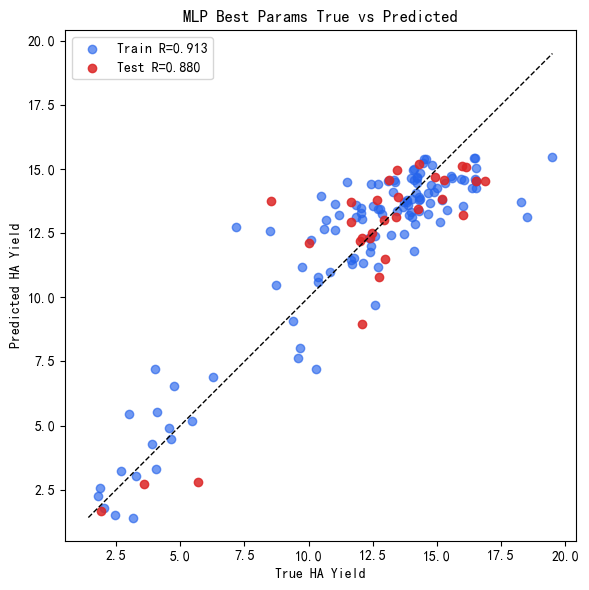

MLP Best Parameters:
{'mlp__activation': 'tanh', 'mlp__alpha': 2.5343221083724825e-05, 'mlp__batch_size': 32, 'mlp__beta_1': 0.85, 'mlp__beta_2': 0.999, 'mlp__hidden_layer_sizes': (8,), 'mlp__learning_rate': 'adaptive', 'mlp__learning_rate_init': 0.006627897035983008}

PLS Components: 5
PLS Cumulative Variance Ratio: 97.3286%

===== Cross-Validation Results =====
MSE : 1.8648
RMSE: 1.3656
MAE : 1.0956
MRE : 12.72%
R2  : 0.8642

===== Training Set Metrics =====
MSE: 2.6965
RMSE: 1.6421
MAE: 1.2377
MRE: 12.81%
R2: 0.8337

===== Test Set Metrics =====
MSE: 3.0465
RMSE: 1.7454
MAE: 1.3228
MRE: 12.48%
R2: 0.7501

Results saved to: E:\YRH-HSI\python data\MUST\MLP.xlsx
Visualizations saved to: E:\YRH-HSI\python data\MUST\mlp_best_params_visualization


In [12]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

warnings.filterwarnings("ignore", category=ConvergenceWarning)

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"

output_path = spectra_path.with_name("MLP.xlsx")
output_dir = spectra_path.parent / "mlp_best_params_visualization"
output_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path, header=None)
label_df = pd.read_excel(label_path, header=None)

id_col = "SampleID"
target_col = "HA_Yield"

feature_cols = [f"Feature_{i}" for i in range(1, spectra_df.shape[1])]
spectra_df.columns = [id_col] + feature_cols

label_df = label_df.iloc[:, :2].copy()
label_df.columns = [id_col, target_col]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return 0.0
    return np.corrcoef(y_true, y_pred)[0, 1]

spectra_df[id_col] = spectra_df[id_col].map(normalize_id)
label_df[id_col] = label_df[id_col].map(normalize_id)
label_df[target_col] = pd.to_numeric(label_df[target_col], errors="coerce")

label_check = label_df.groupby(id_col)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()

if conflict_ids:
    raise ValueError(f"The following SampleIDs correspond to multiple different HA Yield values, please check label.xlsx: {conflict_ids}")

label_unique = label_df.drop_duplicates(subset=[id_col], keep="first")
df = spectra_df.merge(label_unique, on=id_col, how="left")

if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col].unique()
    raise ValueError(f"The following SampleIDs cannot find matching HA Yield in label.xlsx: {missing_ids}")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean()).fillna(0)
y = df[target_col].astype(float)

X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 5
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])

if n_components > max_components:
    raise ValueError(f"A maximum of {max_components} PLS components can be extracted from current dataset, cannot set to 5.")

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_standard.values, y.values.reshape(-1, 1))

X_scores = pls.x_scores_
X_reconstructed = X_scores @ pls.x_loadings_.T

ss_total = np.sum(X_standard.values ** 2)
ss_residual = np.sum((X_standard.values - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]

df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col, df[id_col].values)
df_pls[target_col] = y.values

X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col].astype(str)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))

X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

best_params = {
    "mlp__activation": "tanh",
    "mlp__alpha": 2.5343221083724825e-05,
    "mlp__batch_size": 32,
    "mlp__beta_1": 0.85,
    "mlp__beta_2": 0.999,
    "mlp__hidden_layer_sizes": (8,),
    "mlp__learning_rate": "adaptive",
    "mlp__learning_rate_init": 0.006627897035983008
}

model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        solver="adam",
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        max_iter=3000,
        random_state=42
    ))
])

model.set_params(**best_params)

n_splits = min(5, groups_train.nunique())

if n_splits < 2:
    raise ValueError("The number of unique SampleID groups in training set is insufficient to perform GroupKFold cross validation.")

cv = GroupKFold(n_splits=n_splits)

fold_metrics = []
for fold_train, fold_val in cv.split(X_train, y_train, groups=groups_train):
    X_fold_tr, X_fold_val = X_train.iloc[fold_train], X_train.iloc[fold_val]
    y_fold_tr, y_fold_val = y_train.iloc[fold_train], y_train.iloc[fold_val]
    fold_model = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            solver="adam",
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            max_iter=3000,
            random_state=42
        ))
    ])
    fold_model.set_params(**best_params)
    fold_model.fit(X_fold_tr, y_fold_tr)
    y_fold_pred = fold_model.predict(X_fold_val)
    fold_r2 = r2_score(y_fold_val, y_fold_pred)
    fold_mse = mean_squared_error(y_fold_val, y_fold_pred)
    fold_mae = mean_absolute_error(y_fold_val, y_fold_pred)
    fold_mre = np.mean(np.abs(y_fold_val - y_fold_pred) / y_fold_val) * 100
    fold_metrics.append((fold_r2, fold_mse, fold_mae, fold_mre))

fold_metrics.sort(reverse=True, key=lambda x: x[0])
best_fold_r2, cv_mse, cv_mae, cv_mre = fold_metrics[0]
cv_rmse = np.sqrt(cv_mse)
cv_r2 = best_fold_r2

model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_result_df = pd.DataFrame({
    id_col: df_pls.iloc[train_idx][id_col].values,
    "Dataset": "Training",
    "True_HA_Yield": y_train.values,
    "Predicted_HA_Yield": y_train_pred,
    "Residual": y_train.values - y_train_pred
})

test_result_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values,
    "Dataset": "Test",
    "True_HA_Yield": y_test.values,
    "Predicted_HA_Yield": y_test_pred,
    "Residual": y_test.values - y_test_pred
})

all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    try:
        return float(str(x).strip())
    except ValueError:
        return np.inf

all_result_df["Sort_Key_ID"] = all_result_df[id_col].map(id_sort_key)
all_result_df["Group_Index"] = all_result_df.groupby(id_col).cumcount() + 1

all_result_sorted_df = all_result_df.sort_values(
    by=["Sort_Key_ID", "Group_Index"],
    ascending=[True, True]
).drop(columns=["Sort_Key_ID"])

metrics_df = pd.DataFrame({
    "Metric": [
        "PLS_Components",
        "PLS_Cumulative_Variance_Ratio",
        "CV_RMSE_Fixed_Best_Params",
        "Train_R",
        "Test_R",
        "Train_R_Minus_Test_R",
        "Train_R_Greater_Than_Test_R",
        "R_Gap_Less_Equal_0.15",
        "Train_R2",
        "Test_R2",
        "Train_MSE",
        "Test_MSE",
        "Train_RMSE",
        "Test_RMSE",
        "Train_MAE",
        "Test_MAE",
        "Train_MRE_Percent",
        "Test_MRE_Percent"
    ],
    "Value": [
        n_components,
        cumulative_variance_ratio,
        cv_rmse,
        pearson_r(y_train, y_train_pred),
        pearson_r(y_test, y_test_pred),
        pearson_r(y_train, y_train_pred) - pearson_r(y_test, y_test_pred),
        pearson_r(y_train, y_train_pred) > pearson_r(y_test, y_test_pred),
        0 <= (pearson_r(y_train, y_train_pred) - pearson_r(y_test, y_test_pred)) <= 0.15,
        train_r2,
        test_r2,
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_mre,
        test_mre
    ]
})

best_params_df = pd.DataFrame(
    list(best_params.items()),
    columns=["Parameter", "Fixed_Value"]
)

# 仅保留真实vs预测散点图，删除残差图、按ID排序预测曲线图
plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.65, label=f"Train R={pearson_r(y_train, y_train_pred):.3f}", color="#2563EB")
plt.scatter(y_test, y_test_pred, alpha=0.85, label=f"Test R={pearson_r(y_test, y_test_pred):.3f}", color="#DC2626")

min_v = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_v = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("MLP Best Params True vs Predicted")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "true_vs_predicted_train_test.png", dpi=300)
plt.show()

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_5", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    best_params_df.to_excel(writer, sheet_name="best_params", index=False)

print("MLP Best Parameters:")
print(best_params)

print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")

print("\n===== Cross-Validation Results =====")
print(f"MSE : {cv_mse:.4f}")
print(f"RMSE: {cv_rmse:.4f}")
print(f"MAE : {cv_mae:.4f}")
print(f"MRE : {cv_mre:.2f}%")
print(f"R2  : {cv_r2:.4f}")

print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"MRE: {train_mre:.2f}%")
print(f"R2: {train_r2:.4f}")

print(f"\n===== Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"MRE: {test_mre:.2f}%")
print(f"R2: {test_r2:.4f}")

print(f"\nResults saved to: {output_path}")
print(f"Visualizations saved to: {output_dir}")